# Expression20 vs GO

This notebook runs 20 expression-derived MyGeneset/MSigDB signatures against an official GOA human/GO snapshot. The CLI does the enrichment; Python only summarizes the Parquet results.

In [1]:
%%bash
set -euo pipefail
cd "$(git rev-parse --show-toplevel)"
python3 scripts/fetch_mygeneset_eval.py \
  --manifest evals/expression20/sets.tsv \
  --out-dir evals/expression20/generated \
  --skip-existing

Using existing MyGeneset snapshot at evals/expression20/generated


In [2]:
%%bash
set -euo pipefail
cd "$(git rev-parse --show-toplevel)"
python3 scripts/run_expression20_go_demo.py --skip-existing

reused_existing: notebooks/generated/expression20_go_now.parquet


metadata: notebooks/generated/expression20_go_now.yaml


In [3]:
import duckdb
import pandas as pd

from notebooks.display_utils import display_table, metric_cards, repo_root

repo = repo_root()
results = repo / "notebooks/generated/expression20_go_now.parquet"
con = duckdb.connect()
df = con.execute("SELECT * FROM read_parquet(?)", [str(results)]).df()
metric_cards([
    ("significant rows", f"{len(df):,}"),
    ("queries with hits", f"{df['query_id'].nunique():,}"),
    ("GO terms", f"{df['target_id'].nunique():,}"),
])

In [4]:
by_query = (
    df.groupby(["query_id", "query_name"], dropna=False)
    .agg(
        significant_go_terms=("target_id", "count"),
        unique_go_terms=("target_id", "nunique"),
        best_adjusted_p=("p_adjust_bonferroni", "min"),
        max_overlap=("overlap", "max"),
    )
    .reset_index()
    .sort_values(["significant_go_terms", "best_adjusted_p"], ascending=[False, True])
)
display_table(
    by_query,
    caption="GO enrichment counts per Expression20 query",
    max_rows=20,
    formatters={"best_adjusted_p": lambda value: f"{value:.3e}"},
)

query_id,query_name,significant_go_terms,unique_go_terms,best_adjusted_p,max_overlap
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,gse11386 naive vs memory bcell up,194,194,2.352e-50,191
GSE11057_PBMC_VS_MEM_CD4_TCELL_UP,gse11057 pbmc vs mem cd4 tcell up,176,176,2.705e-34,201
GSE22886_NAIVE_VS_IGG_IGA_MEMORY_BCELL_DN,gse22886 naive vs igg iga memory bcell dn,129,129,3.398e-48,200
GSE10240_CTRL_VS_IL17_AND_IL22_STIM_PRIMARY_BRONCHIAL_EPITHELIAL_CELLS_UP,gse10240 ctrl vs il17 and il22 stim primary bronchial epithelial cells up,85,85,2.016e-35,193
NUNODA_RESPONSE_TO_DASATINIB_IMATINIB_UP,nunoda response to dasatinib imatinib up,80,80,1.925e-19,29
GSE10325_LUPUS_BCELL_VS_LUPUS_MYELOID_UP,gse10325 lupus bcell vs lupus myeloid up,78,78,3.842e-29,193
RAPA_EARLY_UP.V1_UP,rapa early up.v1 up,73,73,1.440e-27,168
GSE7831_UNSTIM_VS_INFLUENZA_STIM_PDC_1H_UP,gse7831 unstim vs influenza stim pdc 1h up,71,71,3.511e-42,204
GSE9960_HEALTHY_VS_SEPSIS_PBMC_UP,gse9960 healthy vs sepsis pbmc up,44,44,5.401e-36,190
GSE18893_CTRL_VS_TNF_TREATED_TCONV_24H_UP,gse18893 ctrl vs tnf treated tconv 24h up,36,36,4.000e-39,202


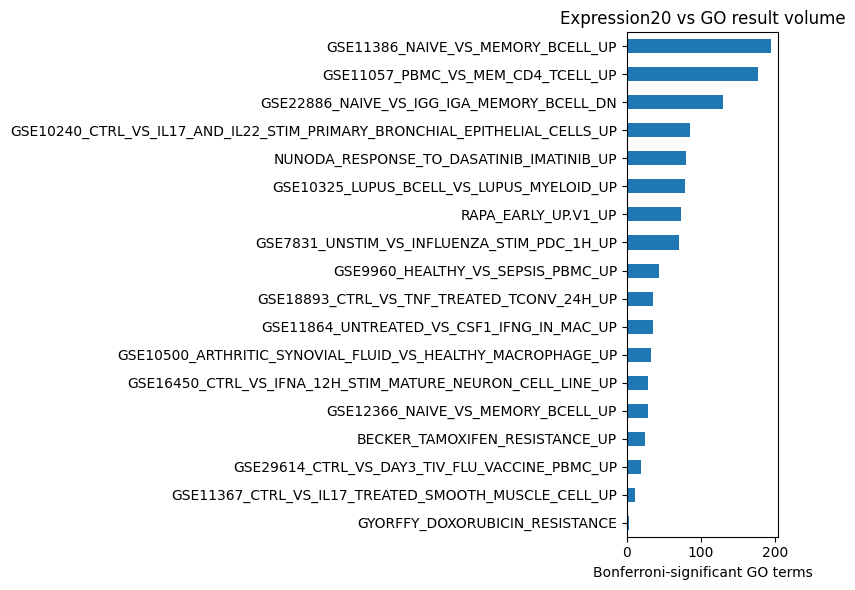

In [5]:
import matplotlib.pyplot as plt

plot_df = by_query.sort_values("significant_go_terms")
ax = plot_df.plot.barh(
    x="query_id",
    y="significant_go_terms",
    legend=False,
    figsize=(8, 6),
)
ax.set_xlabel("Bonferroni-significant GO terms")
ax.set_ylabel("")
ax.set_title("Expression20 vs GO result volume")
plt.tight_layout()

The strongest unfiltered GO hits are often broad terms. For a more useful first look, the next table keeps terms with target size at most 500 genes.

In [6]:
cols = [
    "query_id",
    "target_id",
    "target_name",
    "overlap",
    "query_size",
    "target_size",
    "p_adjust_bonferroni",
]
specific = df.loc[df["target_size"] <= 500].sort_values("p_adjust_bonferroni")
display_table(
    specific,
    columns=cols,
    caption="Top enriched GO terms with target size at most 500 genes",
    max_rows=20,
    formatters={"p_adjust_bonferroni": lambda value: f"{value:.3e}"},
)

query_id,target_id,target_name,overlap,query_size,target_size,p_adjust_bonferroni
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0051276,chromosome organization,28,191,424,1.218e-17
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0098687,chromosomal region,26,191,399,6.877e-16
NUNODA_RESPONSE_TO_DASATINIB_IMATINIB_UP,GO:0044772,mitotic cell cycle phase transition,11,29,130,5.338e-15
NUNODA_RESPONSE_TO_DASATINIB_IMATINIB_UP,GO:0044770,cell cycle phase transition,11,29,142,1.457e-14
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0098813,nuclear chromosome segregation,20,191,223,7.027e-14
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0000280,nuclear division,22,191,305,1.143e-13
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0007059,chromosome segregation,22,191,312,1.861e-13
NUNODA_RESPONSE_TO_DASATINIB_IMATINIB_UP,GO:0000307,cyclin-dependent protein kinase holoenzyme complex,9,29,66,2.760e-13
GSE11386_NAIVE_VS_MEMORY_BCELL_UP,GO:0000793,condensed chromosome,21,191,278,2.986e-13
NUNODA_RESPONSE_TO_DASATINIB_IMATINIB_UP,GO:1902554,serine/threonine protein kinase complex,10,29,120,4.362e-13
